In [1]:
import numpy as np 
import healpy as hp
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
import glob
import seaborn as sns
# sns.set_style("darkgrid")
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from num2words import num2words
from scipy.optimize import curve_fit
from mpl_toolkits import mplot3d
import os
from distfit import distfit

# sns.set(rc={"xtick.bottom": True, "ytick.left": True})
%matplotlib inline
# %matplotlib notebook

## Read Country DB parameters

In [12]:
csv_files = ['./database/China.csv']


#France has 9393 Tx
#DB has 


# --Create an empty dataframe to store the combined data-- #
df = pd.DataFrame()

# Loop through each CSV file and append its contents to the combined dataframe
for csv_file in (csv_files):
    df_temp = pd.read_csv(csv_file)
    df = pd.concat([df, df_temp],ignore_index=True)

df=df.dropna()
power=df['EIRP'].to_numpy()
lat_128=df['Latitude in degrees'].to_numpy()
lon_128=df['Longitude in degrees'].to_numpy()

pix=hp.ang2pix(128,lon_128,lat_128,lonlat=True)

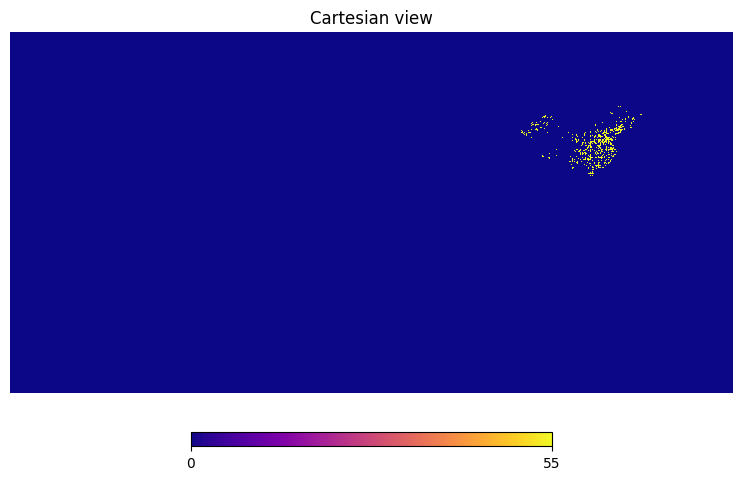

In [13]:

Tx_num_128=np.zeros(hp.nside2npix(128))
for pi in pix:
    Tx_num_128[pi]+=1
hp.cartview(Tx_num_128,flip='geo',cmap='plasma',norm='hist')
plt.show()

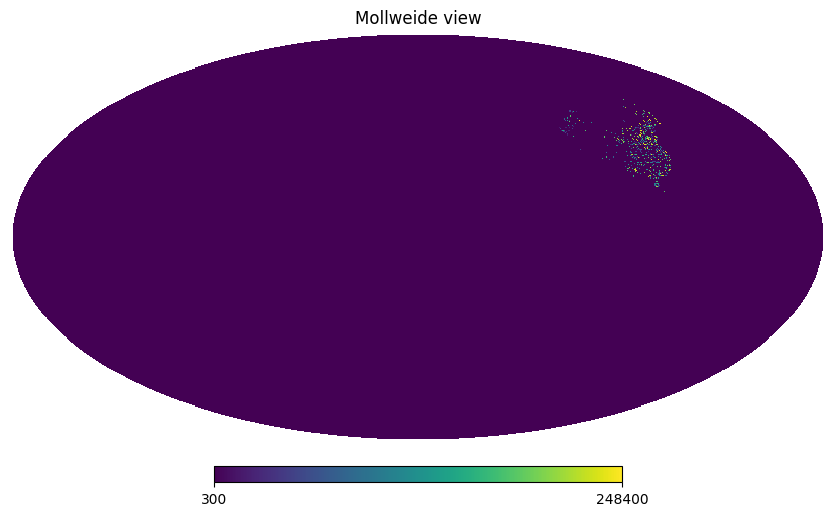

In [14]:
Tx_pow_128=np.zeros(hp.nside2npix(128))
for index,p in enumerate(pix):
    Tx_pow_128[p]+=(power[index])
hp.mollview(Tx_pow_128,flip='geo',cmap='viridis',norm='hist',min=300)
plt.show()

## Fitting PDF to Tx params

In [5]:
fr_df=pd.read_csv('./database/China.csv')
fr_df=fr_df.dropna()
lat=fr_df['Latitude in degrees'].to_numpy()
lon=fr_df['Longitude in degrees'].to_numpy()
power=fr_df['EIRP'].to_numpy()
freq=fr_df['Frequency(MHz)'].to_numpy()

In [6]:
#bin width using Freedman Diaconis rule#
def FDrule(inarg):
    qr1,qr2=np.percentile(inarg,[25,75])
    iqr=qr2-qr1
    width=(2*iqr)/(np.size(iqr)**(1/3))
    return int(width)

## Model Latitude

[distfit] >INFO> fit
[distfit] >INFO> transform
[distfit] >INFO> [alpha          ] [0.07 sec] [RSS: 0.00221483] [loc=-88.748 scale=2033.066]
[distfit] >INFO> [anglit         ] [0.02 sec] [RSS: 0.00133044] [loc=34.439 scale=22.980]
[distfit] >INFO> [arcsine        ] [0.04 sec] [RSS: 0.0169819] [loc=16.456 scale=35.844]
[distfit] >INFO> [beta           ] [0.06 sec] [RSS: 0.00131711] [loc=16.084 scale=37.886]
[distfit] >INFO> [betaprime      ] [0.11 sec] [RSS: 0.00243531] [loc=-0.397 scale=42.646]
[distfit] >INFO> [bradford       ] [0.03 sec] [RSS: 0.00777323] [loc=16.500 scale=35.800]
[distfit] >INFO> [burr           ] [0.29 sec] [RSS: 0.00245927] [loc=-0.295 scale=39.491]
[distfit] >INFO> [cauchy         ] [0.00 sec] [RSS: 0.00459429] [loc=34.371 scale=5.159]
[distfit] >INFO> [chi            ] [0.07 sec] [RSS: 0.00207205] [loc=1.470 scale=10.574]
[distfit] >INFO> [chi2           ] [0.07 sec] [RSS: 0.00211903] [loc=-7.902 scale=0.668]
[distfit] >INFO> [cosine         ] [0.01 sec] [RSS: 0

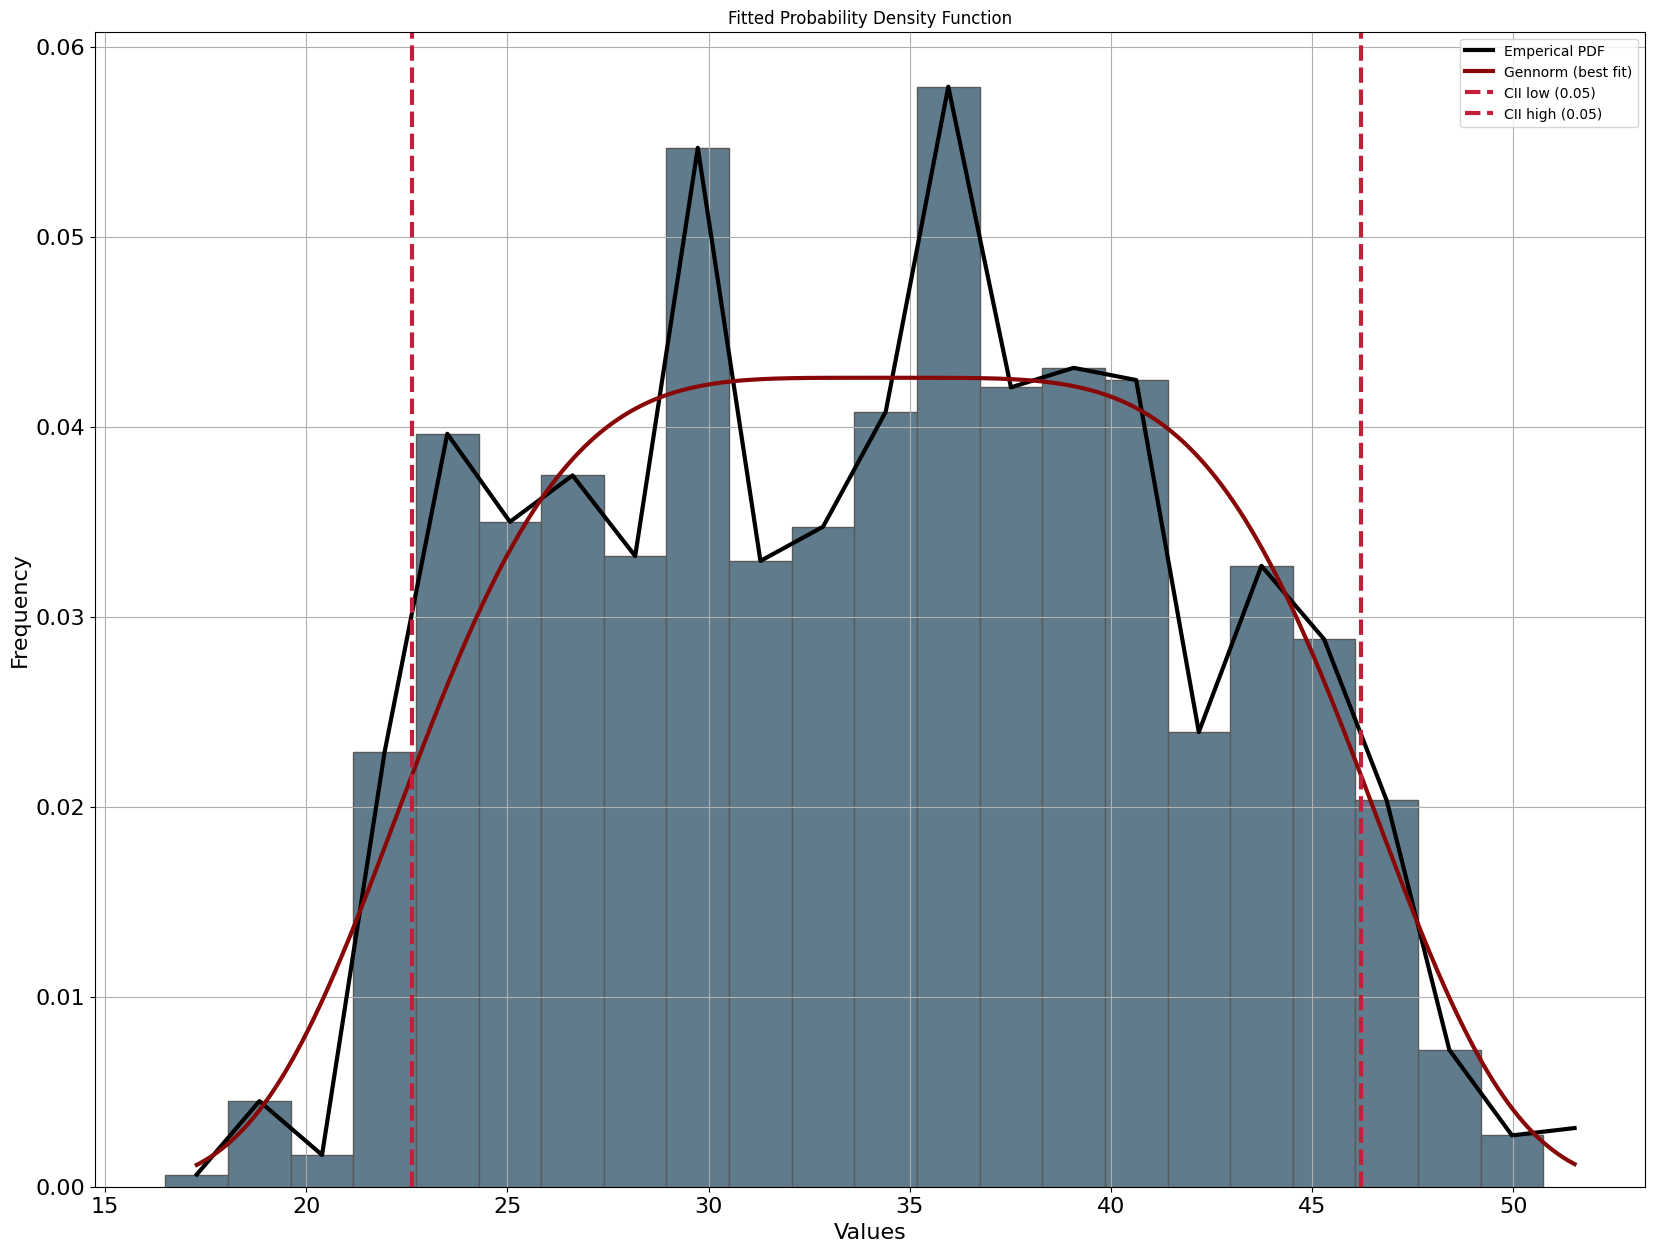

Best fitted distribution: gennorm
Parameters: (4.482088517752195, 34.418692650772186, 12.8698739370767)


In [7]:
binw=FDrule(lat)
# Fit a probability density function
distlat = distfit(distr='full',bins=binw)
distlat.fit_transform(lat)

# Plot the fitted distribution
distlat.plot()
plt.title('Fitted Probability Density Function')
plt.show()

# Get information about the best-fitted distribution
print("Best fitted distribution:", distlat.model['name'])
print("Parameters:", distlat.model['params'])


## Model longitude

[distfit] >INFO> fit
[distfit] >INFO> transform
[distfit] >INFO> [alpha          ] [0.07 sec] [RSS: 0.0017228] [loc=-218.527 scale=9170.981]
[distfit] >INFO> [anglit         ] [0.02 sec] [RSS: 0.00329199] [loc=105.543 scale=39.566]
[distfit] >INFO> [arcsine        ] [0.05 sec] [RSS: 0.0100733] [loc=74.563 scale=59.601]
[distfit] >INFO> [beta           ] [0.12 sec] [RSS: 0.000716969] [loc=-230427.833 scale=230565.043]
[distfit] >INFO> [betaprime      ] [0.12 sec] [RSS: 0.00172055] [loc=-4.652 scale=369.204]
[distfit] >INFO> [bradford       ] [0.03 sec] [RSS: 0.00556761] [loc=74.231 scale=60.300]
[distfit] >INFO> [burr           ] [0.37 sec] [RSS: 0.000632986] [loc=-0.766 scale=121.098]
[distfit] >INFO> [cauchy         ] [0.00 sec] [RSS: 0.00169203] [loc=112.447 scale=6.273]
[distfit] >INFO> [chi            ] [0.07 sec] [RSS: 0.00141934] [loc=-200.255 scale=16.156]
[distfit] >INFO> [chi2           ] [0.07 sec] [RSS: 0.00162271] [loc=-35.818 scale=0.483]
[distfit] >INFO> [cosine         ]

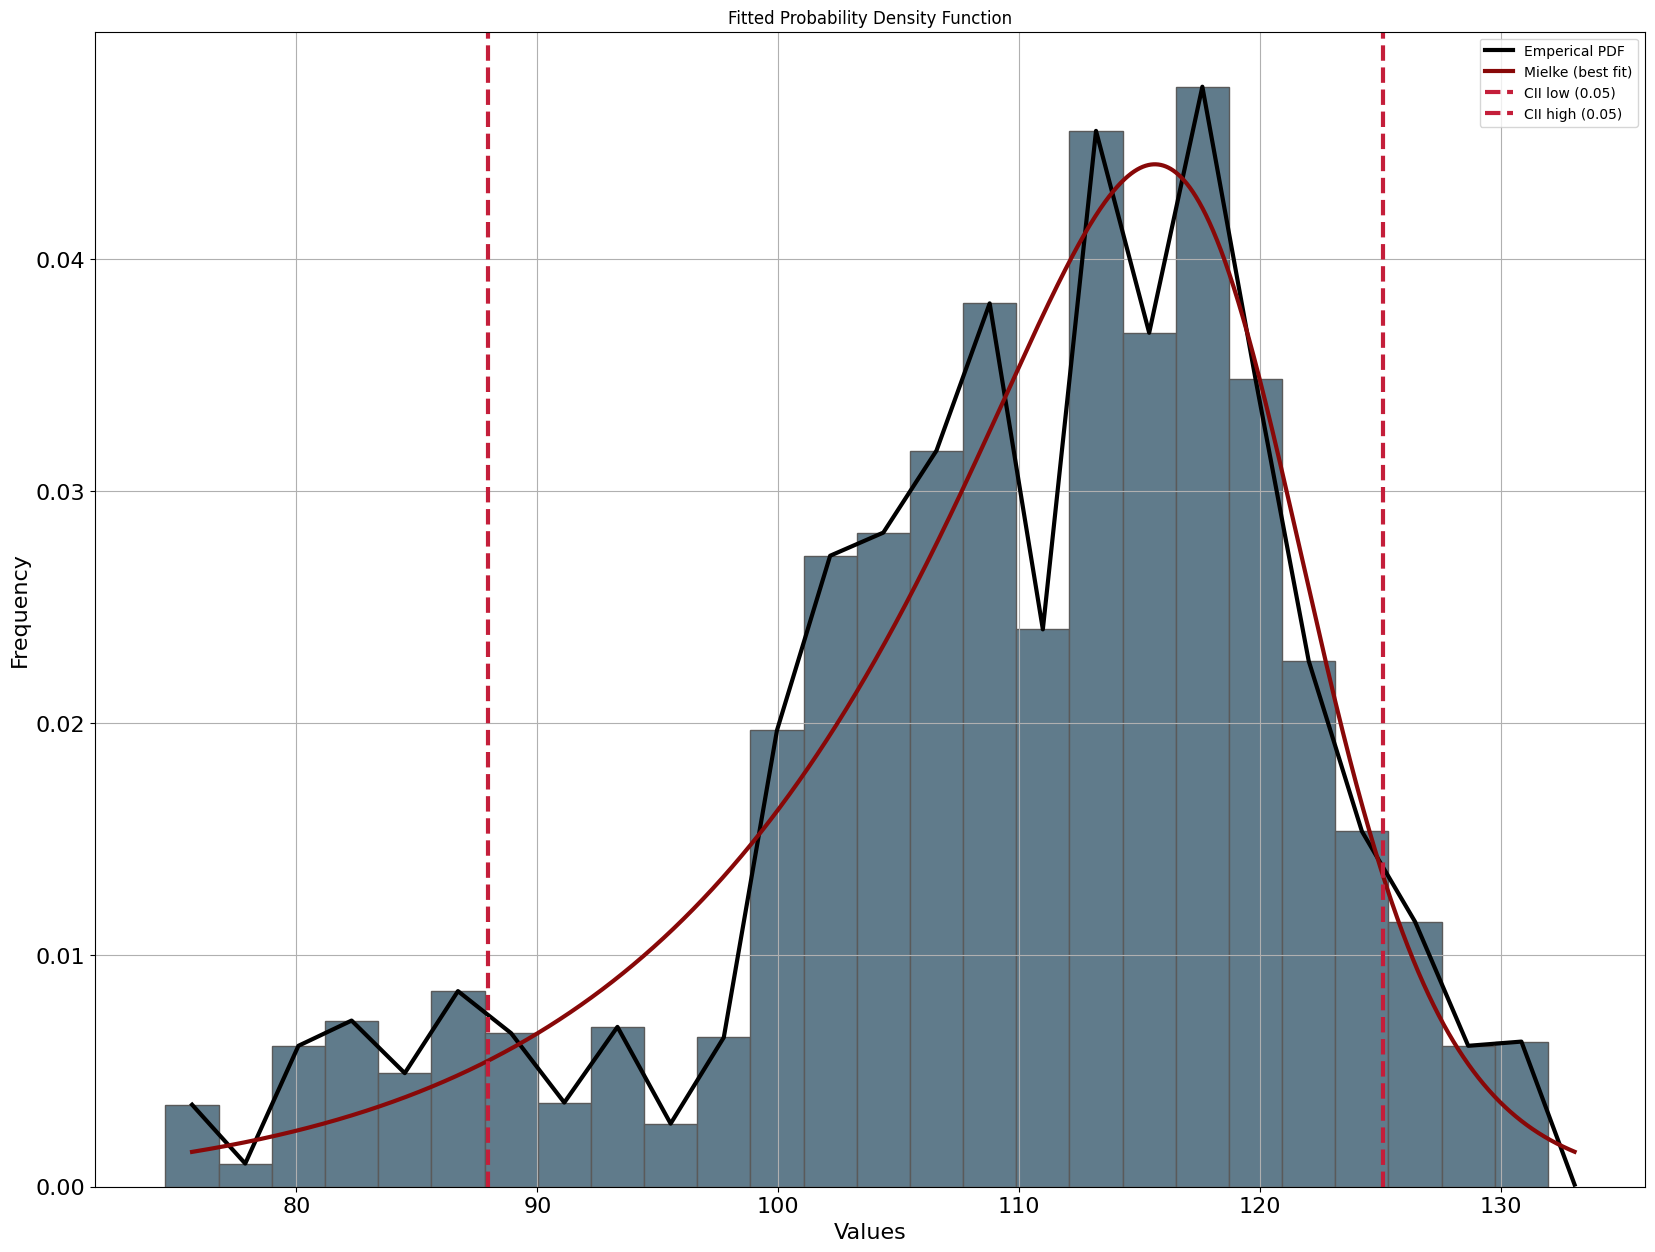

Best fitted distribution: mielke
Parameters: (9.614919291230489, 38.37458806384033, -0.6775453667145117, 121.01101362772519)


In [8]:
binwi=FDrule(lon)
# Fit a probability density function
distlon = distfit(distr='full',bins=binwi)
distlon.fit_transform(lon)

# Plot the fitted distribution
distlon.plot()
plt.title('Fitted Probability Density Function')
plt.show()

# Get information about the best-fitted distribution
print("Best fitted distribution:", distlon.model['name'])
print("Parameters:", distlon.model['params'])


## Generate lon lat vals

In [30]:
newlat=distlat.generate(9186)
np.max(newlon)

148.98452886994173

In [10]:
newlon=distlon.generate(9186,)

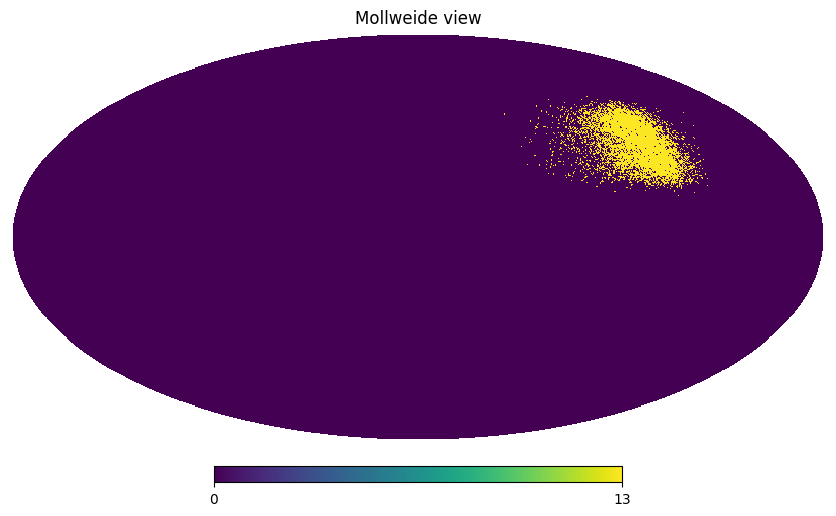

In [11]:
newfrpix=hp.ang2pix(128,newlon,newlat,lonlat=True)
newmap=np.zeros(hp.nside2npix(128))
for pp in newfrpix:
    newmap[pp]+=1
hp.mollview(newmap,flip='geo',norm='hist')

In [15]:
valpix=np.argwhere(Tx_num_128)
diff=Tx_num_128[valpix]-newmap[valpix]

## Model Tx power

[distfit] >INFO> fit
[distfit] >INFO> transform
[distfit] >INFO> [powerlaw] [0.06 sec] [RSS: 0.000171581] [loc=-0.000 scale=63000.000]


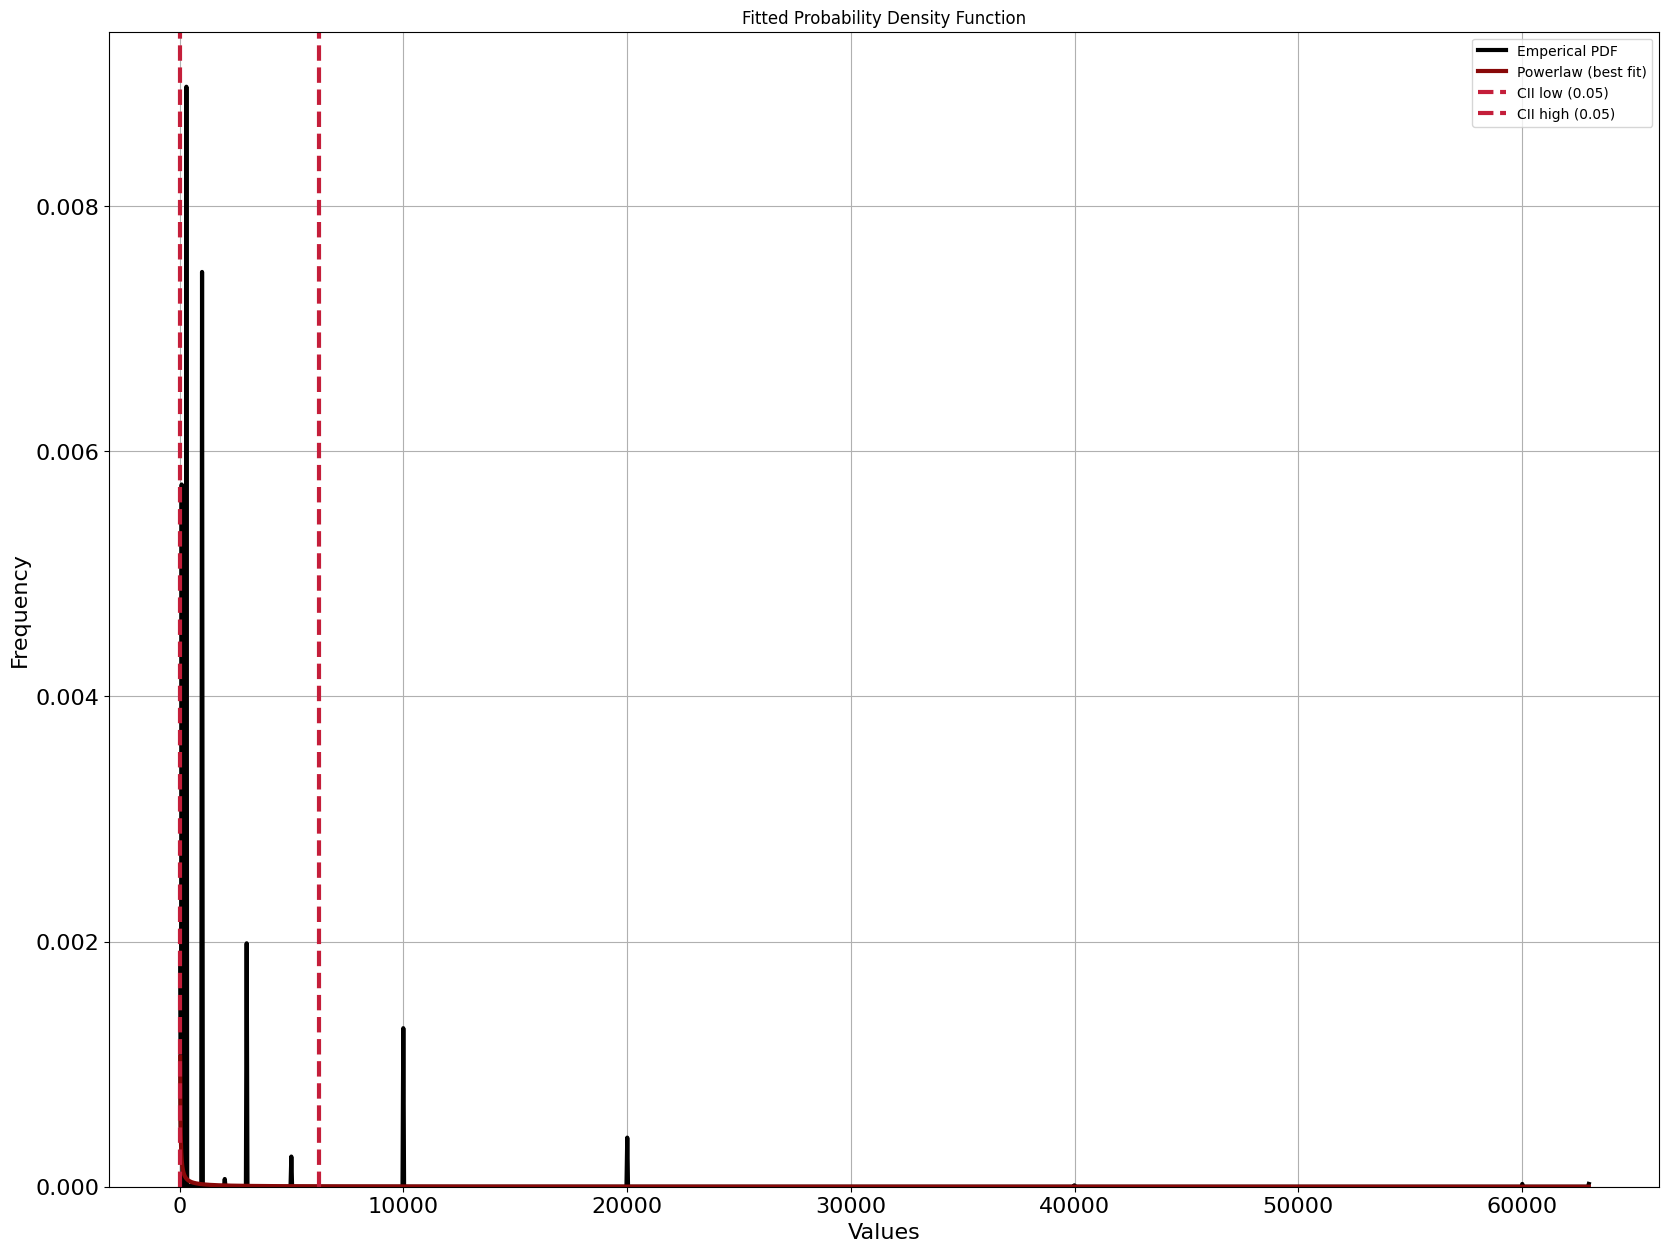

Best fitted distribution: powerlaw
Parameters: (0.022184378175272655, -2.2250738585072014e-308, 63000.00000000001)


In [16]:
powbin=FDrule(power)
# Fit a probability density function
distpow = distfit(distr='powerlaw',bins=powbin)
distpow.fit_transform(power)

# Plot the fitted distribution
distpow.plot()
plt.title('Fitted Probability Density Function')
plt.show()

# Get information about the best-fitted distribution
print("Best fitted distribution:", distpow.model['name'])
print("Parameters:", distpow.model['params'])


In [17]:
newpow=distpow.generate(9186)

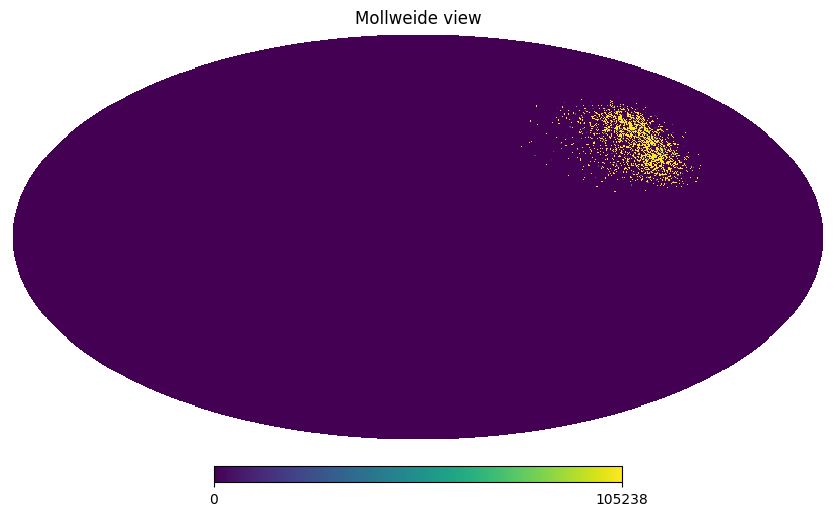

In [23]:
new_powmap=np.zeros(hp.nside2npix(128))
for index,p in enumerate(newfrpix):
    new_powmap[p]+=(newpow[index])
hp.mollview(new_powmap,flip='geo',cmap='viridis',norm='hist')
plt.show()

## Tx number per pixel residuals

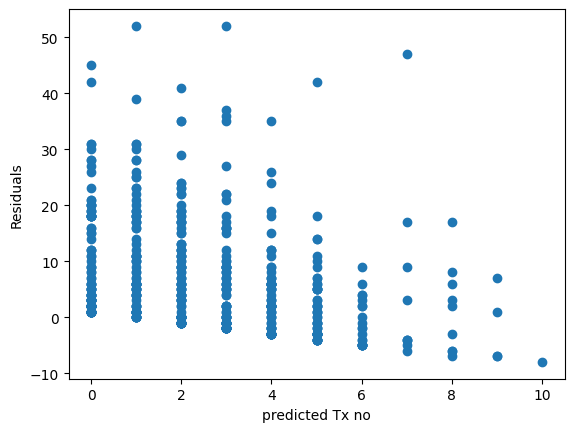

In [24]:
plt.scatter(newmap[valpix],diff)
plt.xlabel('predicted Tx no')
plt.ylabel('Residuals')
plt.show()

In [25]:
power_res=Tx_pow_128[valpix]-new_powmap[valpix]

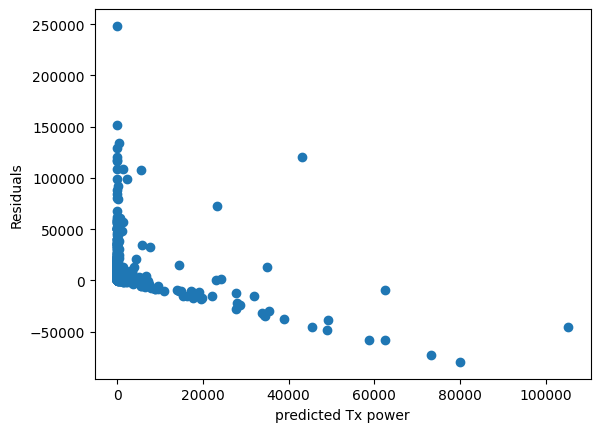

In [27]:
plt.scatter(new_powmap[valpix],power_res)
plt.xlabel('predicted Tx power')
plt.ylabel('Residuals')
# plt.xscale('log')
plt.show()